# 01 - Download and explore the raw data  (Req 1)

**Dataset:** Sentiment140 (Stanford, 2009) - 1.6 million tweets labelled from emoticons, plus a small **hand-labelled** test file (498 tweets, includes neutral).

**Goal:** get the data and look at it *before* cleaning, so every cleaning rule is based on evidence.

Run all cells top to bottom. The download is done by `src/01_download.py` (about 80 MB the first time).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 110)
pd.set_option('display.width', 200)

%run ../src/01_download.py

Files in data/raw: ['testdata.manual.2009.06.14.csv', 'training.1600000.processed.noemoticon.csv', 'trainingandtestdata.zip']


Train rows: 1,600,000   Manual test rows: 498
   target    tweet_id                          date     query             user                                                                                                           text
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to ...
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton  is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. ...
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus                      @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF                                                                my whole body feels itchy and like its on fire 
4   

## Load both files
The files have no header row, so we name the columns ourselves.

In [2]:
COLUMNS = ['target', 'tweet_id', 'date', 'query', 'user', 'text']
train = pd.read_csv('../data/raw/training.1600000.processed.noemoticon.csv', names=COLUMNS, encoding='utf-8', encoding_errors='replace')
test = pd.read_csv('../data/raw/testdata.manual.2009.06.14.csv', names=COLUMNS, encoding='utf-8', encoding_errors='replace')
train[['target', 'date', 'user', 'text']].head(6)

,target,date,user,text
0,0,Mon Apr 06 22:19:45 PDT 2009,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to ..."
1,0,Mon Apr 06 22:19:49 PDT 2009,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. ...
2,0,Mon Apr 06 22:19:53 PDT 2009,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
3,0,Mon Apr 06 22:19:57 PDT 2009,ElleCTF,my whole body feels itchy and like its on fire
4,0,Mon Apr 06 22:19:57 PDT 2009,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over th..."
5,0,Mon Apr 06 22:20:00 PDT 2009,joy_wolf,@Kwesidei not the whole crew


## Label balance
`target`: 0 = negative, 2 = neutral, 4 = positive. The big file has **no neutral class** - neutral only exists in the small hand-labelled file. Teammates on Req 2 need to know this.

          train (emoticon labels)  test (hand labels)
target                                               
negative                   800000                 177
neutral                         0                 139
positive                   800000                 182


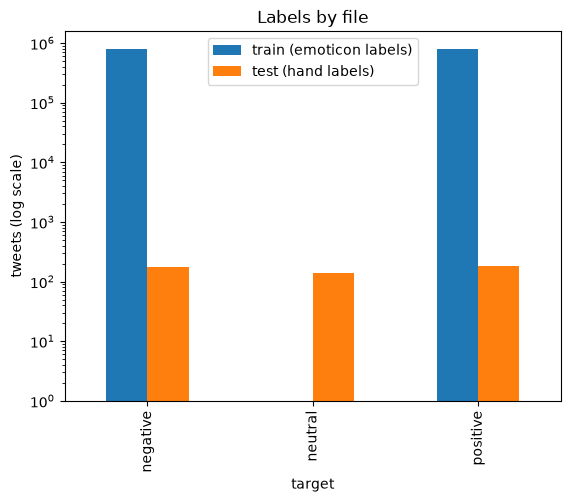

In [3]:
summary = pd.DataFrame({'train (emoticon labels)': train['target'].value_counts(),
                        'test (hand labels)': test['target'].value_counts()}).fillna(0).astype(int)
summary.index = summary.index.map({0: 'negative', 2: 'neutral', 4: 'positive'})
print(summary)
summary.plot.bar(title='Labels by file', log=True)
plt.ylabel('tweets (log scale)'); plt.show()

## Time span
Trends over time (Req 3, 7) need dates. The big file covers about three months, but not every day has tweets.

From 2009-04-06 22:19:45 to 2009-06-25 10:28:31 | days with tweets: 48


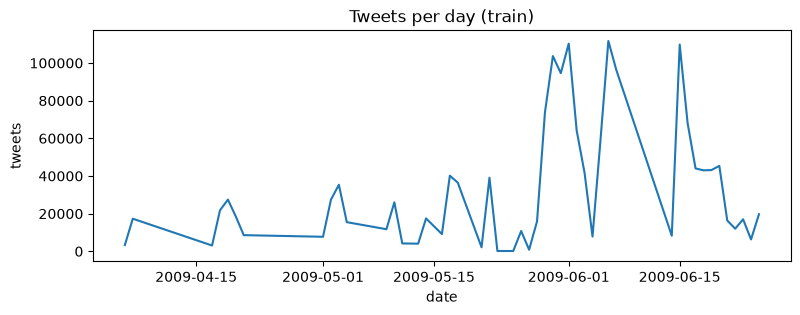

Timezone labels in train: <ArrowStringArray>
['PDT']
Length: 1, dtype: str | in test: <ArrowStringArray>
['UTC']
Length: 1, dtype: str


In [4]:
dates = pd.to_datetime(train['date'].str.replace(r' (PDT|UTC) ', ' ', regex=True), format='%a %b %d %H:%M:%S %Y')
per_day = dates.dt.date.value_counts().sort_index()
print('From', dates.min(), 'to', dates.max(), '| days with tweets:', len(per_day))
per_day.plot(title='Tweets per day (train)', figsize=(9, 3))
plt.ylabel('tweets'); plt.show()
print('Timezone labels in train:', train['date'].str.extract(r' (PDT|UTC) ')[0].unique(),
      '| in test:', test['date'].str.extract(r' (PDT|UTC) ')[0].unique())

## Topics
The big file has no topic (`NO_QUERY`). The hand-labelled file has a search term per tweet, which we use as `topic_group`.

In [5]:
print(train['query'].unique())
print(test['query'].nunique(), 'topics in test, e.g.')
test['query'].value_counts().head(8)

<ArrowStringArray>
['NO_QUERY']
Length: 1, dtype: str
81 topics in test, e.g.


query
time warner              35
nike                     25
"night at the museum"    25
gm                       22
kindle2                  20
safeway                  20
lebron                   18
dentist                  17
Name: count, dtype: int64

## Problems we must handle
These numbers decide the cleaning rules in notebook 02.

In [6]:
problems = {
    'missing text': int(train['text'].isna().sum()),
    'repeated tweet_id (same tweet stored twice)': int(train['tweet_id'].duplicated().sum()),
    'exact duplicate text': int(train['text'].duplicated().sum()),
    'tweets containing a URL': int(train['text'].str.contains('http').sum()),
    'tweets with HTML escapes (&amp; &quot; ...)': int(train['text'].str.contains('&amp;|&lt;|&gt;|&quot;').sum()),
    'test tweets that also appear in train': int(test['tweet_id'].isin(train['tweet_id']).sum()),
    'distinct users in train': int(train['user'].nunique()),
}
pd.Series(problems, name='count')

missing text                                        0
repeated tweet_id (same tweet stored twice)      1685
exact duplicate text                            18534
tweets containing a URL                         70183
tweets with HTML escapes (&amp; &quot; ...)     94458
test tweets that also appear in train               0
distinct users in train                        659775
Name: count, dtype: int64

## What we did and why
We downloaded the raw files **unchanged** into `data/raw/` and checked their quality. There are duplicated IDs and texts, URLs and HTML escapes, so cleaning and de-duplication are needed -> **notebook 02**.